# BrushCue Example: Custom Spacial Shader

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/custom_spacial_shader.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/custom-spacial-shader

In [ ]:
!pip install brushcue

[wgpu] using backend Metal — adapter 'Apple M5' (IntegratedGpu), driver ''


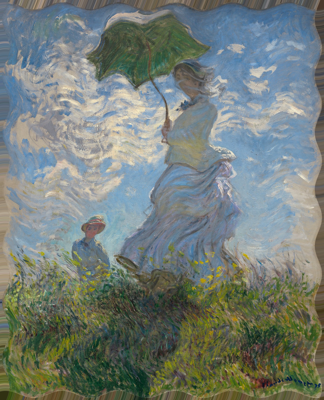

In [1]:
import io
from PIL import Image

import brushcue as bc

input_image = bc.Composition.monet_women_with_parasol()
amplitude = 20.0
frequency = 0.02
input_bounds = input_image.bounds()
graph = input_image.spacial_effect_shader(
    "// Edit this body to displace each pixel. `position` is the output pixel location in working-space pixels, and `sample(p)` reads the source color at p.\n// NOTE: `sample` returns transparency outside the image, so clamp the target to `image_bounds` to keep edges solid.\nlet offset = vec2<f32>(sin(position.y * frequency) * amplitude, cos(position.x * frequency) * amplitude);\nlet sample_pos = clamp(position + offset, image_bounds.xy + vec2<f32>(0.5), image_bounds.zw - vec2<f32>(0.5));\nreturn sample(sample_pos);",
    "// You can write your helper functions here if you need them.",
    (amplitude * 1.5),
    bc.Dictionary.create()
    .add("amplitude", amplitude)
    .add("frequency", frequency)
    .add("image_bounds", input_bounds),
    bc.ColorRepresentation.srgb(),
)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
